Model loaded successfully!
Scaler loaded successfully!
X_test shape: (95, 5)
y_test shape: (95,)
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction completed!
MAE  : 22.77 km
MSE  : 868.51
RMSE : 29.47 km
R²   : 0.9046


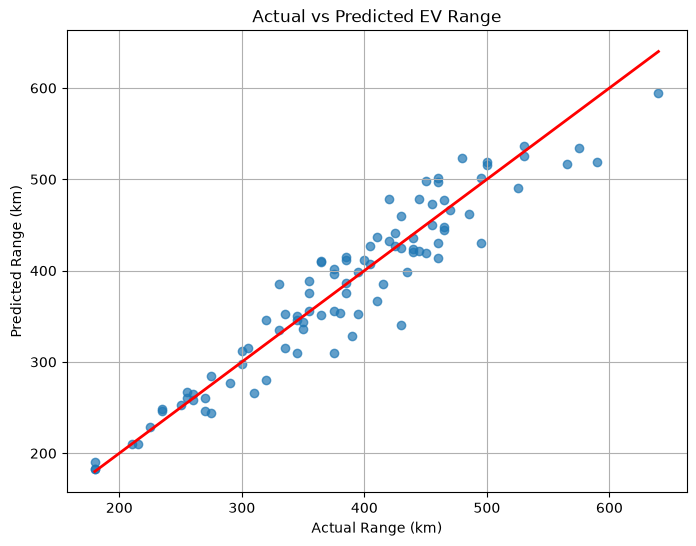

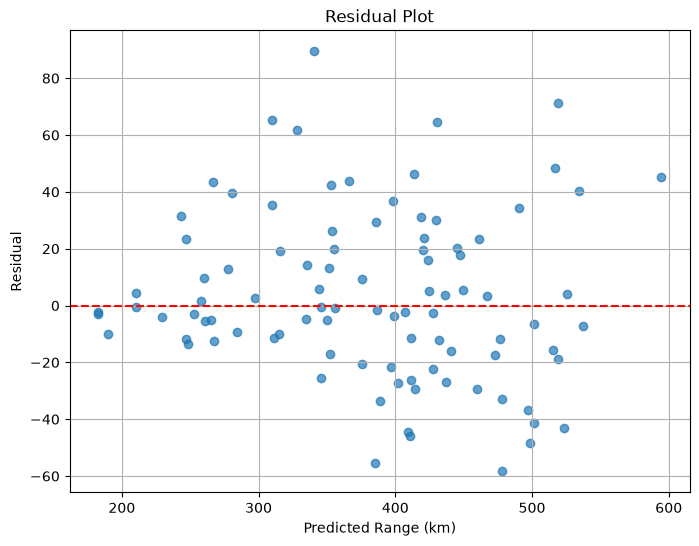

,Actual Range (km),Predicted Range (km),Prediction Error (km),Absolute Error
35,430,340.608368,89.391632,89.391632
71,590,518.734314,71.265686,71.265686
38,375,309.796631,65.203369,65.203369
72,495,430.522766,64.477234,64.477234
32,390,328.280457,61.719543,61.719543
25,420,478.398285,-58.398285,58.398285
26,330,385.325928,-55.325928,55.325928
37,450,498.346649,-48.346649,48.346649
44,565,516.658325,48.341675,48.341675
27,460,413.585144,46.414856,46.414856


In [1]:
# ==========================================
# Model Evaluation
# EV Range Prediction using ANN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# Load the trained model

model = load_model("../Models/final_ev_range_ann_model.keras")

print("Model loaded successfully!")

# Load the scaler

scaler = joblib.load("../Models/scaler.pkl")

print("Scaler loaded successfully!")

# Load processed datasets

X_test_scaled = pd.read_csv(
    "../Data/Processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../Data/Processed/y_test.csv"
).squeeze()

print("X_test shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)

# Predict EV Range

y_pred = model.predict(X_test_scaled)

# Convert prediction into 1D array

y_pred = y_pred.flatten()

print("Prediction completed!")

comparison = pd.DataFrame({

    "Actual Range (km)": y_test,
    "Predicted Range (km)": y_pred

})

comparison["Prediction Error (km)"] = (

    comparison["Actual Range (km)"] -

    comparison["Predicted Range (km)"]

)

comparison.head(10)

# Calculate evaluation metrics

mae = mean_absolute_error(

    y_test,

    y_pred

)

mse = mean_squared_error(

    y_test,

    y_pred

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    y_pred

)

print("="*40)

print(f"MAE  : {mae:.2f} km")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f} km")

print(f"R²   : {r2:.4f}")

print("="*40)

# Actual vs Predicted Range Plot

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_pred,

    alpha=0.7

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red",

    linewidth=2

)

plt.xlabel("Actual Range (km)")

plt.ylabel("Predicted Range (km)")

plt.title("Actual vs Predicted EV Range")

plt.grid(True)

plt.show()

# Residuals Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(

    y_pred,

    residuals,

    alpha=0.7

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted Range (km)")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


# Histogram of Prediction Errors

comparison["Absolute Error"] = np.abs(

    comparison["Prediction Error (km)"]

)

comparison.sort_values(

    by="Absolute Error",

    ascending=False

).head(10)


# Largest Prediction Errors

comparison["Absolute Error"] = np.abs(

    comparison["Prediction Error (km)"]

)

comparison.sort_values(

    by="Absolute Error",

    ascending=False

).head(10)




In [2]:
# Save the prediction results to a CSV file
comparison.to_csv(

    "../Results/model_predictions.csv",

    index=False

)

print("Predictions saved successfully!")

Predictions saved successfully!


In [3]:
# Save the Evaluation Metrics to a CSV file
metrics = pd.DataFrame({

    "Metric":[

        "MAE",

        "MSE",

        "RMSE",

        "R2 Score"

    ],

    "Value":[

        mae,

        mse,

        rmse,

        r2

    ]

})

metrics.to_csv(

    "../Results/evaluation_metrics.csv",

    index=False

)

metrics

,Metric,Value
0,MAE,22.766954
1,MSE,868.513000
2,RMSE,29.470545
3,R2 Score,0.904568
